In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pandas as pd
from tensorflow import keras

In [2]:
MAIN_DIR = "D:\IMAGE2MASS"
IMAGE_DIR = MAIN_DIR + '\\' + 'imagery' + '\\' + 'realsense_overhead'
DISH_DATA_CAFE_1_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe1.csv"
DISH_DATA_CAFE_2_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe2.csv"

In [3]:
cafe1 = pd.read_csv(DISH_DATA_CAFE_1_FILE, header=None, on_bad_lines='skip')
cafe2 = pd.read_csv(DISH_DATA_CAFE_2_FILE, header=None, on_bad_lines='skip')

In [4]:
cafe1.head()

,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,ingr_0000000508,soy sauce,3.398568,1.801241,...,0.000425,0.019754,0.004248,ingr_0000000513,millet,3.414345,4.063071,0.034143,0.80920,0.119502
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,ingr_0000000433,roasted potatoes,17.000000,23.970000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,ingr_0000000312,pepper,0.300716,0.120286,...,0.000000,0.000000,0.000000,ingr_0000000524,parsley,0.752816,0.279295,0.006023,0.04818,0.021832
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,ingr_0000000448,jalapenos,0.192961,0.055959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,ingr_0000000471,cherry tomatoes,55.000000,9.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Set les colonnes importantes manuellement
cafe1.columns = ['dish_id', 'total_mass', 'total_calories', 'total_fat', 
                'total_carb', 'total_protein', 'ingr_id'] + \
               [f'col_{i}' for i in range(7, cafe1.shape[1])]

cafe2.columns = ['dish_id', 'total_mass', 'total_calories', 'total_fat', 
                'total_carb', 'total_protein', 'ingr_id'] + \
               [f'col_{i}' for i in range(7, cafe2.shape[1])]

In [6]:
# Load sans header
cafe1 = pd.read_csv(DISH_DATA_CAFE_1_FILE, header=None, on_bad_lines='skip')
cafe2 = pd.read_csv(DISH_DATA_CAFE_2_FILE, header=None, on_bad_lines='skip')

def create_proper_columns(df):
    """Create proper ingredient column names"""
    
    # Base columns (first 7)
    base_cols = ['dish_id', 'total_mass', 'total_calories', 'total_fat', 
                'total_carb', 'total_protein', 'ingr_id']
    
    # Calculate how many ingredients we have
    remaining_cols = df.shape[1] - 7
    num_ingredients = remaining_cols // 6  # 6 colonnes par ingrédient

    print(f"Detected {num_ingredients} max ingredients")
    
    # Create ingredient columns
    ingredient_cols = []
    for i in range(1, num_ingredients + 1):
        ingredient_cols.extend([
            f'ingr_{i}_name', 
            f'ingr_{i}_grams',
            f'ingr_{i}_calories',
            f'ingr_{i}_fat',
            f'ingr_{i}_carb',
            f'ingr_{i}_protein'
        ])
    
    # Handle any extra columns
    total_expected = 7 + len(ingredient_cols)
    if df.shape[1] > total_expected:
        extra_cols = [f'extra_{i}' for i in range(total_expected, df.shape[1])]
        ingredient_cols.extend(extra_cols)
    
    return base_cols + ingredient_cols

# Set columns for both dataframes
cafe1.columns = create_proper_columns(cafe1)
cafe2.columns = create_proper_columns(cafe2)

print("Columns set correctly:")
print("Base columns:", cafe1.columns[:7].tolist())
print("First ingredient columns:", cafe1.columns[7:13].tolist())

# Quick check
print(f"\nSample data:")
print(cafe1.head())

Detected 19 max ingredients
Detected 9 max ingredients
Columns set correctly:
Base columns: ['dish_id', 'total_mass', 'total_calories', 'total_fat', 'total_carb', 'total_protein', 'ingr_id']
First ingredient columns: ['ingr_1_name', 'ingr_1_grams', 'ingr_1_calories', 'ingr_1_fat', 'ingr_1_carb', 'ingr_1_protein']

Sample data:
           dish_id  total_mass  total_calories  total_fat  total_carb  \
0  dish_1561662216  300.794281           193.0  12.387489   28.218290   
1  dish_1562688426  137.569992            88.0   8.256000    5.190000   
2  dish_1561662054  419.438782           292.0  23.838249   26.351543   
3  dish_1562008979  382.936646           290.0  22.224644   10.173570   
4  dish_1560455030   20.590000           103.0   0.148000    4.625000   

   total_protein          ingr_id       ingr_1_name  ingr_1_grams  \
0      18.633970  ingr_0000000508         soy sauce      3.398568   
1      10.297000  ingr_0000000433  roasted potatoes     17.000000   
2      25.910593  ingr_00

In [7]:
cafe1.head()

,dish_id,total_mass,total_calories,total_fat,total_carb,total_protein,ingr_id,ingr_1_name,ingr_1_grams,ingr_1_calories,...,ingr_19_name,ingr_19_grams,ingr_19_calories,ingr_19_fat,ingr_19_carb,ingr_19_protein,extra_121,extra_122,extra_123,extra_124
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,ingr_0000000508,soy sauce,3.398568,1.801241,...,0.000425,0.019754,0.004248,ingr_0000000513,millet,3.414345,4.063071,0.034143,0.80920,0.119502
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,ingr_0000000433,roasted potatoes,17.000000,23.970000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,ingr_0000000312,pepper,0.300716,0.120286,...,0.000000,0.000000,0.000000,ingr_0000000524,parsley,0.752816,0.279295,0.006023,0.04818,0.021832
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,ingr_0000000448,jalapenos,0.192961,0.055959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,ingr_0000000471,cherry tomatoes,55.000000,9.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
cafe1.shape

(4392, 125)

In [9]:
def create_plate_dataset(metadata_df):
    """Extract complete plates for training"""
    
    plate_data = []
    
    for _, row in metadata_df.iterrows():
        plate_data.append({
            'dish_id': row['dish_id'],
            'total_weight': float(row['total_mass']),
            'total_calories': float(row['total_calories']),
            'total_protein': float(row['total_protein']),
            'total_fat': float(row['total_fat']), 
            'total_carb': float(row['total_carb'])
        })
    
    return pd.DataFrame(plate_data)

In [10]:
def create_ingredient_dataset(metadata_df):
    """Extract individual ingredients for training"""
    
    ingredient_data = []
    
    for _, row in metadata_df.iterrows():
        dish_id = row['dish_id']
        num_ingrs = int(row['num_ingrs']) if pd.notna(row['num_ingrs']) else 0
        
        # Extract each ingredient
        for i in range(1, num_ingrs + 1):
            ingr_name = row.get(f'ingr_{i}_name')
            ingr_grams = row.get(f'ingr_{i}_grams') 
            ingr_calories = row.get(f'ingr_{i}_calories')
            ingr_protein = row.get(f'ingr_{i}_protein')
            ingr_fat = row.get(f'ingr_{i}_fat')
            ingr_carb = row.get(f'ingr_{i}_carb')
            
            if pd.notna(ingr_name) and pd.notna(ingr_grams):
                ingredient_data.append({
                    'dish_id': dish_id,
                    'ingredient_name': ingr_name,
                    'weight_grams': float(ingr_grams),
                    'calories': float(ingr_calories) if pd.notna(ingr_calories) else 0,
                    'protein': float(ingr_protein) if pd.notna(ingr_protein) else 0,
                    'fat': float(ingr_fat) if pd.notna(ingr_fat) else 0,
                    'carb': float(ingr_carb) if pd.notna(ingr_carb) else 0
                })
    
    return pd.DataFrame(ingredient_data)

In [11]:
plate_df_1 = create_plate_dataset(cafe1)
plate_df_2 = create_plate_dataset(cafe2)

In [12]:
plate_df_2.head()

,dish_id,total_weight,total_calories,total_protein,total_fat,total_carb
0,dish_1572974428,0.0,74.0,0.0,0.0,0.0
1,dish_1572464692,0.0,56.0,0.0,0.0,0.0
2,dish_1571931594,0.0,66.0,0.0,0.0,0.0
3,dish_1575478635,0.0,132.0,0.0,0.0,0.0
4,dish_1572887017,0.0,274.0,0.0,0.0,0.0


In [13]:
plate_df_2.shape

(191, 6)

In [14]:
plate_df = pd.concat([plate_df_1, plate_df_2], ignore_index=True)

In [15]:
plate_df.shape

(4583, 6)

In [16]:
import os

def map_images_nested_structure(df, base_dir, image_type='rgb'):
    """Map avec structure dish_id/image_type.png"""
    
    print(f"Looking for {image_type}.png in dish_id folders...")
    
    valid_data = []
    missing_images = []
    missing_folders = []
    
    for idx, row in df.iterrows():
        dish_id = row['dish_id']
        
        # Path vers le dossier du dish
        dish_folder = os.path.join(base_dir, dish_id)
        
        # Path vers l'image spécifique
        image_path = os.path.join(dish_folder, f"{image_type}.png")
        
        if os.path.exists(image_path):
            valid_data.append({
                'dish_id': dish_id,
                'image_path': image_path,
                'image_type': image_type,
                'total_weight': row['total_weight'],
                'total_calories': row['total_calories'],
                'total_protein': row['total_protein'],
                'total_fat': row['total_fat'],
                'total_carb': row['total_carb']
            })
        elif os.path.exists(dish_folder):
            # Folder exists but image missing
            missing_images.append(dish_id)
        else:
            # Folder doesn't exist
            missing_folders.append(dish_id)
    
    mapped_df = pd.DataFrame(valid_data)
    
    print(f"Successfully mapped: {len(mapped_df)}")
    print(f"Missing {image_type}.png: {len(missing_images)}")
    print(f"Mising dish folders: {len(missing_folders)}")
    print(f"Success rate: {len(mapped_df)/len(df)*100:.1f}%")
    
    return mapped_df, missing_images, missing_folders


# Map RGB images
mapped_rgb_dataset, missing_rgb, missing_folders = map_images_nested_structure(
    plate_df, 
    IMAGE_DIR, 
    'rgb'
)

print(f"\nFinal RGB dataset: {len(mapped_rgb_dataset)} images")
print("Sample paths:")
for i in range(min(3, len(mapped_rgb_dataset))):
    print(f"  {mapped_rgb_dataset.iloc[i]['image_path']}")

Looking for rgb.png in dish_id folders...
Successfully mapped: 3079
Missing rgb.png: 0
Mising dish folders: 1504
Success rate: 67.2%

Final RGB dataset: 3079 images
Sample paths:
  D:\IMAGE2MASS\imagery\realsense_overhead\dish_1561662216\rgb.png
  D:\IMAGE2MASS\imagery\realsense_overhead\dish_1561662054\rgb.png
  D:\IMAGE2MASS\imagery\realsense_overhead\dish_1562008979\rgb.png


In [17]:
mapped_rgb_dataset.head()

,dish_id,image_path,image_type,total_weight,total_calories,total_protein,total_fat,total_carb
0,dish_1561662216,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,rgb,300.794281,193.0,18.633970,12.387489,28.218290
1,dish_1561662054,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,rgb,419.438782,292.0,25.910593,23.838249,26.351543
2,dish_1562008979,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,rgb,382.936646,290.0,35.345387,22.224644,10.173570
3,dish_1560455030,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,rgb,20.590000,103.0,0.956000,0.148000,4.625000
4,dish_1558372433,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,rgb,74.360001,143.0,20.020000,0.286000,0.429000


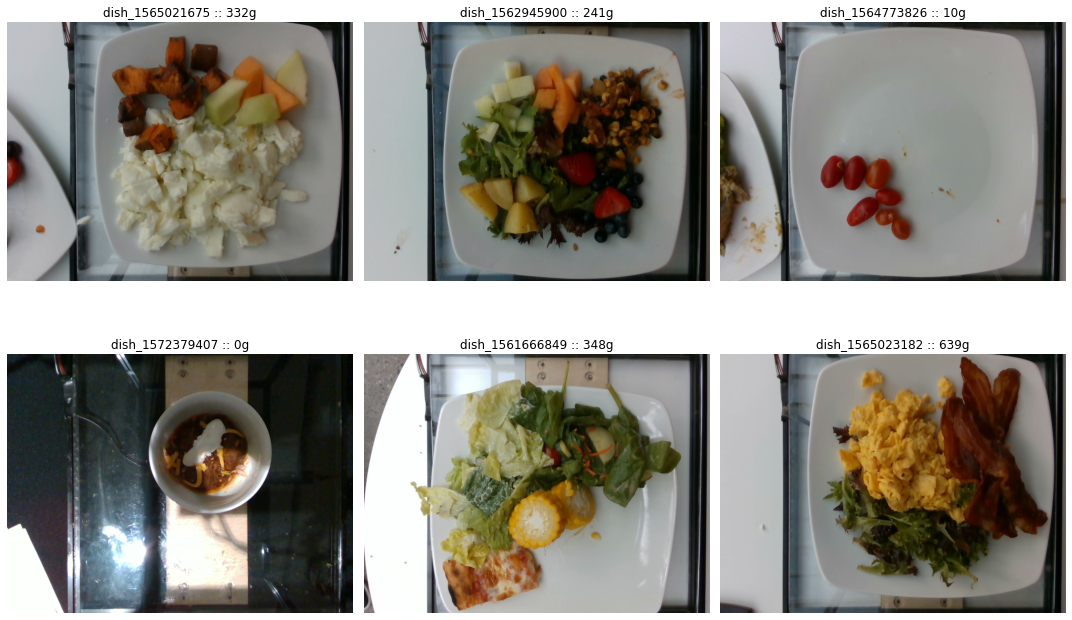

In [18]:
from PIL import Image
def quick_look_at_data(df, n_samples=6):
    """Simple : regarde quelques images du dataset"""
    
    # Take random samples
    sample_df = df.sample(n_samples).reset_index(drop=True)
    
    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i in range(n_samples):
        row = sample_df.iloc[i]
        
        img = Image.open(row['image_path']).convert('RGB')
        
        axes[i].imshow(img)
        axes[i].set_title(f"{row['dish_id']} :: {row['total_weight']:.0f}g")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

quick_look_at_data(mapped_rgb_dataset)

In [19]:
def load_images_for_training(df):
    """Convertir TOUTES les images en matrix pour le ML"""
    
    images = []
    calories = []
    
    for _, row in df.iterrows():
        # Load image
        img = Image.open(row['image_path'])
        img = img.convert('RGB')
        img = img.resize((224, 224))
        
        # Convert to matrix
        img_array = np.array(img) / 255.0
        
        images.append(img_array)
        calories.append(row['total_calories'])  
    
    # Return matrices pour training
    return np.array(images), np.array(calories)

# Usage : POUR LE ML
X_train, y_train = load_images_for_training(mapped_rgb_dataset)

In [20]:
y_train

array([193., 292., 290., ...,  15., 329., 132.])